# (07) paint: Poisson img

**Motivation**: host = ```chewie```, device = ```cuda:0``` <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_TemporalSC'))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

In [3]:
from PIL import Image

poisson_img = pjoin(tmp_dir, 'poisson.jpg')
poisson_img = Image.open(poisson_img).convert('L')
poisson_img = np.array(poisson_img)

poisson_img.shape

(1341, 1000)

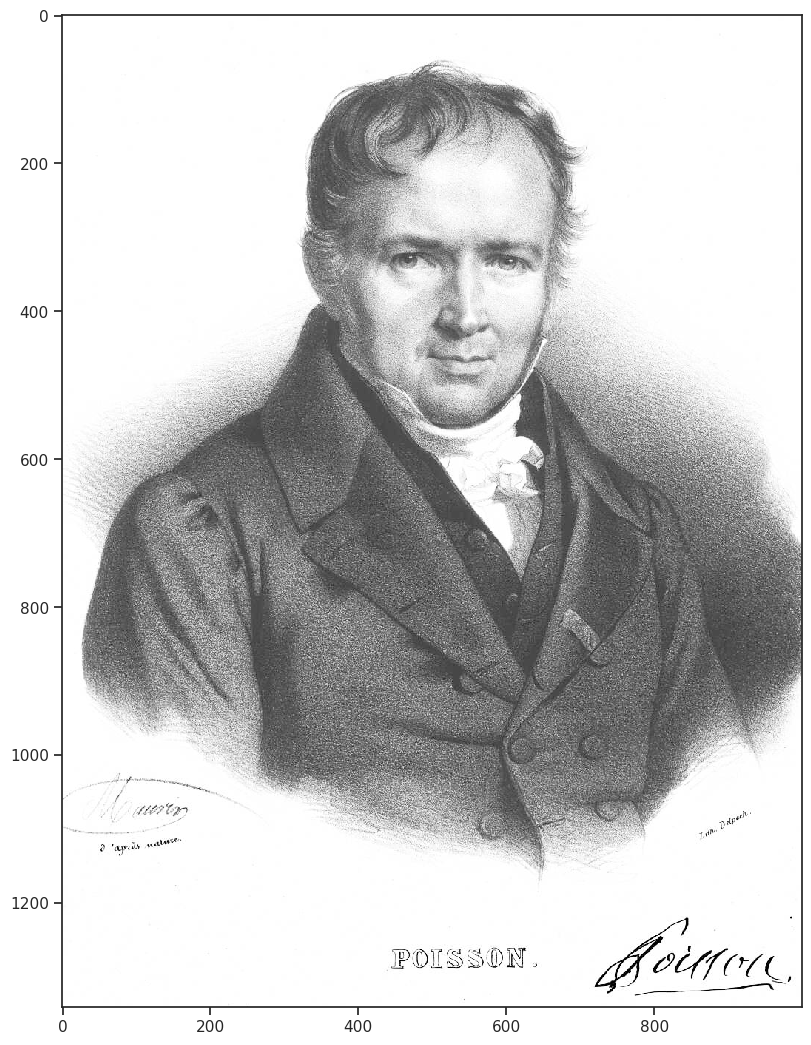

In [4]:
fig, ax = create_figure(1, 1, (8, 30))
ax.imshow(poisson_img, cmap='Greys_r');

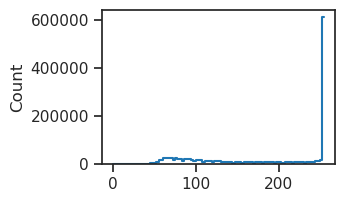

In [5]:
histplot(poisson_img.ravel());

In [6]:
bw = torch.from_numpy(poisson_img).float().to(device=device)
bw = bw.unsqueeze(0).unsqueeze(1)
bw.shape

torch.Size([1, 1, 1341, 1000])

In [7]:
from utils.imgproc import do_process


wht, *_ = do_process(bw, device=device, crop_size=0)

# shift/rescale
wht_shift_rescale = (wht - wht.mean()) / wht.std()
wht_shift_rescale *= 0.4

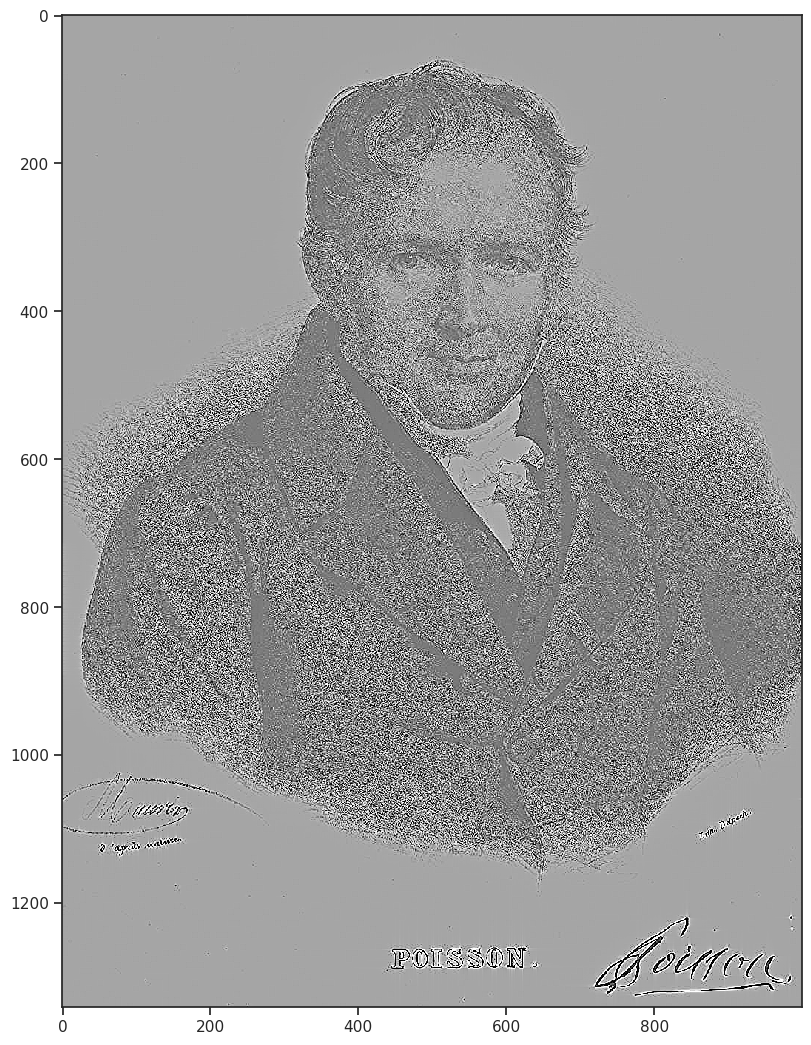

In [8]:
fig, ax = create_figure(1, 1, (8, 30))
ax.imshow(tonp(wht_shift_rescale.squeeze()), vmin=-1, vmax=1, cmap='Greys_r');

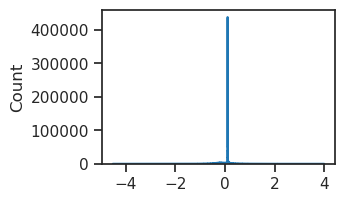

In [9]:
histplot(wht_shift_rescale.ravel());